In [1]:
# ============================================================
# FSDL 2022 - Lab 1 (Modernized)
# Deep Neural Networks in PyTorch
# ============================================================

# Install lightweight, actively maintained packages

!pip -q install torch torchvision matplotlib tqdm

In [2]:
# ============================================================
# Imports
# ============================================================

import random
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim

from torchvision import datasets
from torchvision import transforms

from torch.utils.data import DataLoader

from tqdm.auto import tqdm

# ------------------------------------------------------------
# Reproducibility
# ------------------------------------------------------------

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# ------------------------------------------------------------
# Device
# ------------------------------------------------------------

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print(f"Using device: {device}")

if device.type == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}")

# ------------------------------------------------------------
# PyTorch Version
# ------------------------------------------------------------

print(f"PyTorch Version: {torch.__version__}")

Using device: cpu
PyTorch Version: 2.11.0+cpu


In [3]:
# ============================================================
# Download FashionMNIST
# ============================================================

transform = transforms.ToTensor()

train_dataset = datasets.FashionMNIST(
    root="data",
    train=True,
    download=True,
    transform=transform
)

test_dataset = datasets.FashionMNIST(
    root="data",
    train=False,
    download=True,
    transform=transform
)

print(f"Training samples : {len(train_dataset):,}")
print(f"Testing samples  : {len(test_dataset):,}")

classes = train_dataset.classes

print("\nClasses:")

for i, name in enumerate(classes):
    print(f"{i}: {name}")

100%|██████████| 26.4M/26.4M [00:01<00:00, 14.8MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 312kB/s]
100%|██████████| 4.42M/4.42M [00:00<00:00, 5.64MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 2.20MB/s]


Training samples : 60,000
Testing samples  : 10,000

Classes:
0: T-shirt/top
1: Trouser
2: Pullover
3: Dress
4: Coat
5: Sandal
6: Shirt
7: Sneaker
8: Bag
9: Ankle boot


Image Tensor Shape : torch.Size([1, 28, 28])
Image Data Type    : torch.float32
Label              : 9
Class Name         : Ankle boot


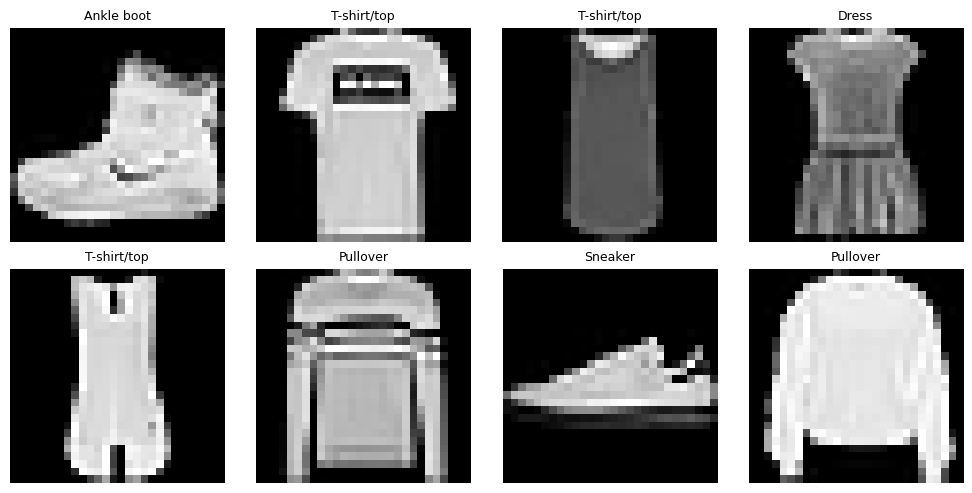


Tensor Properties
-------------------------
Shape : torch.Size([1, 28, 28])
Dimensions : 3
Height : 28
Width : 28

Minimum Pixel Value : 0.0
Maximum Pixel Value : 1.0


In [4]:
# ============================================================
# Explore the Dataset
# ============================================================

image, label = train_dataset[0]

print("Image Tensor Shape :", image.shape)
print("Image Data Type    :", image.dtype)
print("Label              :", label)
print("Class Name         :", classes[label])

# ------------------------------------------------------------
# Visualize Sample Images
# ------------------------------------------------------------

fig, axes = plt.subplots(2, 4, figsize=(10, 5))

for ax, (img, lbl) in zip(axes.flat, train_dataset):

    ax.imshow(img.squeeze(), cmap="gray")
    ax.set_title(classes[lbl], fontsize=9)
    ax.axis("off")

plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# Tensor Information
# ------------------------------------------------------------

print("\nTensor Properties")
print("-------------------------")

print("Shape :", image.shape)
print("Dimensions :", image.ndim)
print("Height :", image.shape[1])
print("Width :", image.shape[2])

print("\nMinimum Pixel Value :", image.min().item())
print("Maximum Pixel Value :", image.max().item())

In [5]:
# ============================================================
# Tensor Basics
# ============================================================

print("=" * 60)
print("Tensor Operations")
print("=" * 60)

# Create tensors
a = torch.tensor([1.0, 2.0, 3.0])
b = torch.tensor([4.0, 5.0, 6.0])

print("Tensor A:", a)
print("Tensor B:", b)

# ------------------------------------------------------------
# Basic Operations
# ------------------------------------------------------------

print("\nAddition")
print(a + b)

print("\nSubtraction")
print(a - b)

print("\nMultiplication")
print(a * b)

print("\nDivision")
print(a / b)

# ------------------------------------------------------------
# Matrix Multiplication
# ------------------------------------------------------------

matrix1 = torch.randn(2, 3)
matrix2 = torch.randn(3, 4)

result = matrix1 @ matrix2

print("\nMatrix Shapes")
print("Matrix 1:", matrix1.shape)
print("Matrix 2:", matrix2.shape)
print("Result  :", result.shape)

# ------------------------------------------------------------
# Reshaping
# ------------------------------------------------------------

tensor = torch.arange(12)

print("\nOriginal Shape:", tensor.shape)

tensor = tensor.reshape(3, 4)

print("Reshaped:")
print(tensor)

# ------------------------------------------------------------
# Tensor Statistics
# ------------------------------------------------------------

print("\nStatistics")

print("Mean :", tensor.float().mean())
print("Std  :", tensor.float().std())
print("Max  :", tensor.max())
print("Min  :", tensor.min())

Tensor Operations
Tensor A: tensor([1., 2., 3.])
Tensor B: tensor([4., 5., 6.])

Addition
tensor([5., 7., 9.])

Subtraction
tensor([-3., -3., -3.])

Multiplication
tensor([ 4., 10., 18.])

Division
tensor([0.2500, 0.4000, 0.5000])

Matrix Shapes
Matrix 1: torch.Size([2, 3])
Matrix 2: torch.Size([3, 4])
Result  : torch.Size([2, 4])

Original Shape: torch.Size([12])
Reshaped:
tensor([[ 0,  1,  2,  3],
        [ 4,  5,  6,  7],
        [ 8,  9, 10, 11]])

Statistics
Mean : tensor(5.5000)
Std  : tensor(3.6056)
Max  : tensor(11)
Min  : tensor(0)


Train batches: 938
Test batches : 157

Batch Information
----------------------------
Images Shape : torch.Size([64, 1, 28, 28])
Labels Shape : torch.Size([64])
Image dtype  : torch.float32
Label dtype  : torch.int64

First 10 Labels
tensor([6, 1, 9, 7, 4, 5, 1, 1, 2, 3])


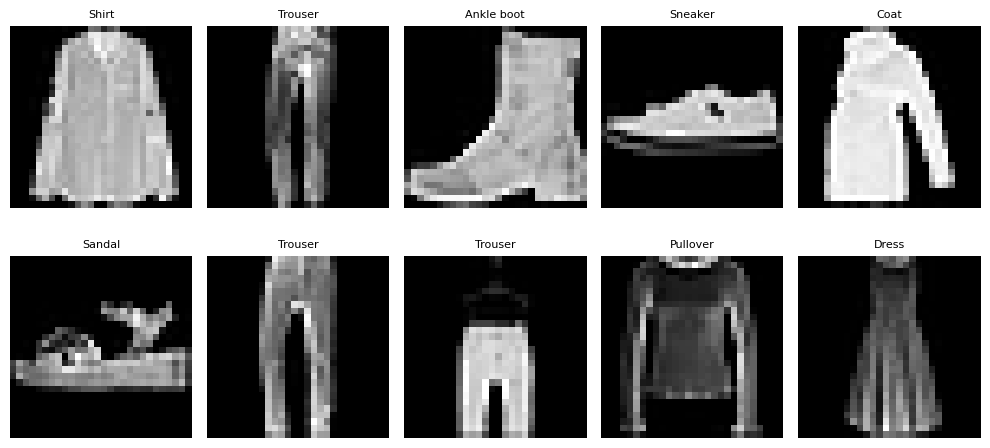

In [6]:
# ============================================================
# DataLoaders
# ============================================================

BATCH_SIZE = 64

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

print("Train batches:", len(train_loader))
print("Test batches :", len(test_loader))

# ------------------------------------------------------------
# Inspect One Batch
# ------------------------------------------------------------

images, labels = next(iter(train_loader))

print("\nBatch Information")
print("----------------------------")

print("Images Shape :", images.shape)
print("Labels Shape :", labels.shape)

print("Image dtype  :", images.dtype)
print("Label dtype  :", labels.dtype)

print("\nFirst 10 Labels")

print(labels[:10])

# ------------------------------------------------------------
# Visualize Batch
# ------------------------------------------------------------

fig, axes = plt.subplots(2, 5, figsize=(10, 5))

for ax, img, lbl in zip(
    axes.flat,
    images[:10],
    labels[:10]
):

    ax.imshow(
        img.squeeze(),
        cmap="gray"
    )

    ax.set_title(classes[lbl], fontsize=8)

    ax.axis("off")

plt.tight_layout()
plt.show()

In [7]:
# ============================================================
# Define a Simple Neural Network
# ============================================================

class SimpleMLP(nn.Module):
    """
    A simple Multi-Layer Perceptron (MLP) for FashionMNIST.
    """

    def __init__(self):
        super().__init__()

        self.network = nn.Sequential(

            # Flatten 28x28 image into a vector of length 784
            nn.Flatten(),

            # Hidden layer
            nn.Linear(28 * 28, 128),

            nn.ReLU(),

            # Output layer (10 classes)
            nn.Linear(128, 10)

        )

    def forward(self, x):

        return self.network(x)


# ------------------------------------------------------------
# Create the model
# ------------------------------------------------------------

model = SimpleMLP().to(device)

print(model)

# ------------------------------------------------------------
# Count trainable parameters
# ------------------------------------------------------------

total_params = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)

print(f"\nTrainable Parameters: {total_params:,}")

SimpleMLP(
  (network): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=128, bias=True)
    (2): ReLU()
    (3): Linear(in_features=128, out_features=10, bias=True)
  )
)

Trainable Parameters: 101,770


Forward Pass
Input Shape : torch.Size([64, 1, 28, 28])
Output Shape: torch.Size([64, 10])

First Sample Logits
tensor([ 0.0961,  0.0347,  0.0475, -0.0115, -0.0212, -0.1899,  0.0731,  0.1131,
        -0.0103, -0.0848], grad_fn=<SelectBackward0>)

Probabilities
tensor([0.1092, 0.1027, 0.1040, 0.0980, 0.0971, 0.0820, 0.1067, 0.1111, 0.0982,
        0.0911], grad_fn=<SelectBackward0>)

Sum of probabilities:
tensor(1.0000, grad_fn=<SumBackward0>)

First 10 Predictions
tensor([7, 7, 0, 0, 7, 0, 0, 7, 0, 7])

Ground Truth
tensor([1, 4, 5, 7, 2, 5, 9, 9, 3, 7])


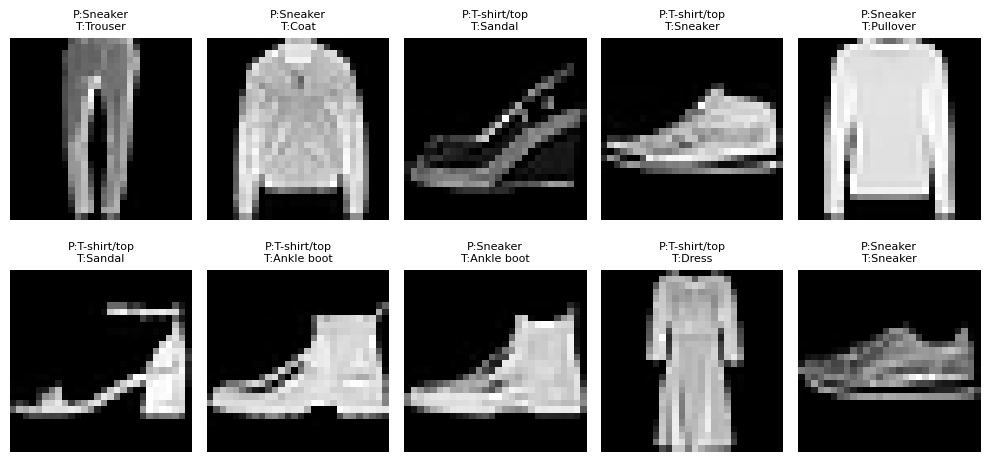

In [8]:
# ============================================================
# Forward Pass
# ============================================================

# Get one mini-batch
images, labels = next(iter(train_loader))

images = images.to(device)
labels = labels.to(device)

# Forward propagation
outputs = model(images)

print("=" * 60)
print("Forward Pass")
print("=" * 60)

print("Input Shape :", images.shape)
print("Output Shape:", outputs.shape)

# ------------------------------------------------------------
# Inspect Raw Outputs (Logits)
# ------------------------------------------------------------

print("\nFirst Sample Logits")

print(outputs[0])

# ------------------------------------------------------------
# Convert Logits to Probabilities
# ------------------------------------------------------------

probabilities = torch.softmax(
    outputs,
    dim=1
)

print("\nProbabilities")

print(probabilities[0])

print("\nSum of probabilities:")

print(probabilities[0].sum())

# ------------------------------------------------------------
# Predicted Classes
# ------------------------------------------------------------

predictions = outputs.argmax(dim=1)

print("\nFirst 10 Predictions")

print(predictions[:10])

print("\nGround Truth")

print(labels[:10])

# ------------------------------------------------------------
# Visualize Predictions
# ------------------------------------------------------------

fig, axes = plt.subplots(2, 5, figsize=(10,5))

for ax, image, pred, true in zip(
    axes.flat,
    images[:10].cpu(),
    predictions[:10].cpu(),
    labels[:10].cpu()
):

    ax.imshow(image.squeeze(), cmap="gray")

    ax.set_title(
        f"P:{classes[pred]}\nT:{classes[true]}",
        fontsize=8
    )

    ax.axis("off")

plt.tight_layout()
plt.show()

In [9]:
# ============================================================
# Loss Function & Optimizer
# ============================================================

# CrossEntropyLoss is the standard loss function
# for multi-class classification.

criterion = nn.CrossEntropyLoss()

# Adam optimizer updates the model's parameters
# using gradients computed during backpropagation.

optimizer = optim.Adam(
    model.parameters(),
    lr=0.001
)

print("=" * 60)
print("Loss Function & Optimizer")
print("=" * 60)

print("Loss Function:")
print(criterion)

print("\nOptimizer:")
print(optimizer)

# ------------------------------------------------------------
# Compute Initial Loss
# ------------------------------------------------------------

loss = criterion(
    outputs,
    labels
)

print(f"\nInitial Loss: {loss.item():.4f}")

# ------------------------------------------------------------
# View Model Parameters
# ------------------------------------------------------------

print("\nModel Parameters")

for name, parameter in model.named_parameters():

    print(
        f"{name:<25}"
        f"{tuple(parameter.shape)}"
    )

Loss Function & Optimizer
Loss Function:
CrossEntropyLoss()

Optimizer:
Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    weight_decay: 0
)

Initial Loss: 2.3264

Model Parameters
network.1.weight         (128, 784)
network.1.bias           (128,)
network.3.weight         (10, 128)
network.3.bias           (10,)


In [10]:
# ============================================================
# Automatic Differentiation (Autograd)
# ============================================================

# Clear old gradients
optimizer.zero_grad()

# Forward pass
outputs = model(images)

# Compute loss
loss = criterion(
    outputs,
    labels
)

print(f"Loss: {loss.item():.4f}")

# ------------------------------------------------------------
# Backpropagation
# ------------------------------------------------------------

loss.backward()

print("\nGradients Computed Successfully!")

# ------------------------------------------------------------
# Inspect Gradients
# ------------------------------------------------------------

first_layer = model.network[1]

print("\nGradient Shape")

print(first_layer.weight.grad.shape)

print("\nGradient Statistics")

print(
    f"Mean : {first_layer.weight.grad.mean():.6f}"
)

print(
    f"Std  : {first_layer.weight.grad.std():.6f}"
)

print(
    f"Max  : {first_layer.weight.grad.max():.6f}"
)

print(
    f"Min  : {first_layer.weight.grad.min():.6f}"
)

# ------------------------------------------------------------
# Update Parameters
# ------------------------------------------------------------

optimizer.step()

print("\n✓ Model parameters updated.")

# ------------------------------------------------------------
# Verify Gradients Exist
# ------------------------------------------------------------

print(
    "\nGradient Exists:",
    first_layer.weight.grad is not None
)

Loss: 2.3264

Gradients Computed Successfully!

Gradient Shape
torch.Size([128, 784])

Gradient Statistics
Mean : 0.000312
Std  : 0.003635
Max  : 0.020342
Min  : -0.017228

✓ Model parameters updated.

Gradient Exists: True


In [11]:
# ============================================================
# Training Loop
# ============================================================

EPOCHS = 5

train_losses = []
train_accuracies = []

for epoch in range(EPOCHS):

    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    progress_bar = tqdm(
        train_loader,
        desc=f"Epoch {epoch+1}/{EPOCHS}"
    )

    for images, labels in progress_bar:

        images = images.to(device)
        labels = labels.to(device)

        # Forward pass
        outputs = model(images)

        # Compute loss
        loss = criterion(
            outputs,
            labels
        )

        # Backpropagation
        optimizer.zero_grad()

        loss.backward()

        optimizer.step()

        # Statistics
        running_loss += loss.item()

        predictions = outputs.argmax(dim=1)

        correct += (
            predictions == labels
        ).sum().item()

        total += labels.size(0)

        progress_bar.set_postfix(
            loss=f"{loss.item():.4f}"
        )

    epoch_loss = running_loss / len(train_loader)
    epoch_accuracy = correct / total

    train_losses.append(epoch_loss)
    train_accuracies.append(epoch_accuracy)

    print(
        f"\nEpoch {epoch+1}"
        f" | Loss: {epoch_loss:.4f}"
        f" | Accuracy: {epoch_accuracy:.2%}"
    )

Epoch 1/5:   0%|          | 0/938 [00:00<?, ?it/s]


Epoch 1 | Loss: 0.5505 | Accuracy: 80.95%


Epoch 2/5:   0%|          | 0/938 [00:00<?, ?it/s]


Epoch 2 | Loss: 0.3986 | Accuracy: 85.86%


Epoch 3/5:   0%|          | 0/938 [00:00<?, ?it/s]


Epoch 3 | Loss: 0.3606 | Accuracy: 87.09%


Epoch 4/5:   0%|          | 0/938 [00:00<?, ?it/s]


Epoch 4 | Loss: 0.3365 | Accuracy: 87.88%


Epoch 5/5:   0%|          | 0/938 [00:00<?, ?it/s]


Epoch 5 | Loss: 0.3135 | Accuracy: 88.71%


In [12]:
# ============================================================
# Validation Loop
# ============================================================

model.eval()

correct = 0
total = 0

validation_loss = 0.0

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        loss = criterion(
            outputs,
            labels
        )

        validation_loss += loss.item()

        predictions = outputs.argmax(dim=1)

        correct += (
            predictions == labels
        ).sum().item()

        total += labels.size(0)

validation_loss /= len(test_loader)

validation_accuracy = correct / total

print("=" * 60)
print("Validation Results")
print("=" * 60)

print(f"Validation Loss     : {validation_loss:.4f}")
print(f"Validation Accuracy : {validation_accuracy:.2%}")

# ------------------------------------------------------------
# Compare Training vs Validation
# ------------------------------------------------------------

print("\nTraining Accuracy   : "
      f"{train_accuracies[-1]:.2%}")

print("Validation Accuracy : "
      f"{validation_accuracy:.2%}")

if validation_accuracy >= train_accuracies[-1] - 0.05:
    print("\n✓ Model generalizes reasonably well.")
else:
    print("\n⚠ Possible overfitting.")

Validation Results
Validation Loss     : 0.3980
Validation Accuracy : 86.17%

Training Accuracy   : 88.71%
Validation Accuracy : 86.17%

✓ Model generalizes reasonably well.


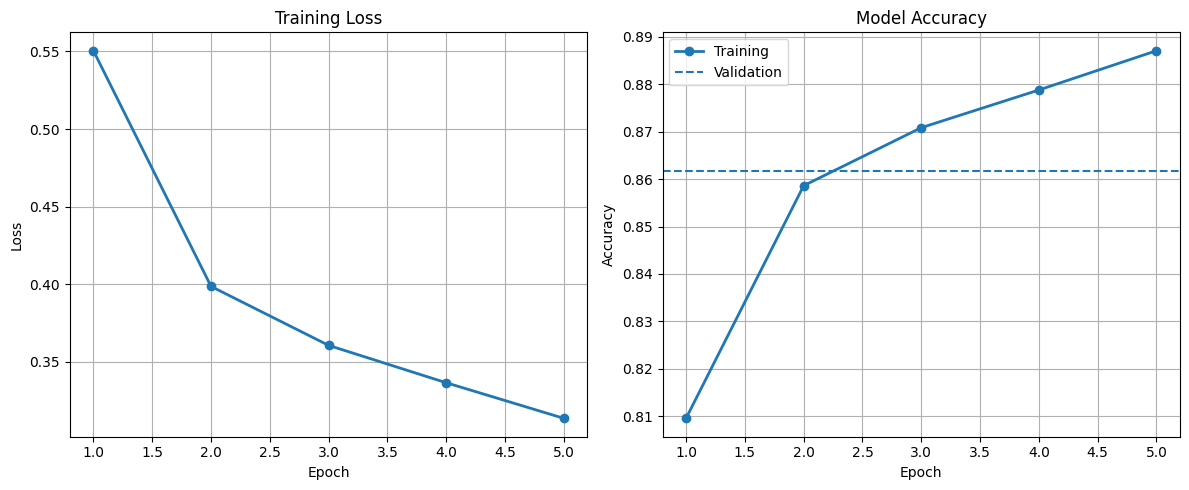

Training Summary
Final Training Loss     : 0.3135
Final Training Accuracy : 88.71%
Validation Accuracy     : 86.17%


In [13]:
# ============================================================
# Training History
# ============================================================

plt.figure(figsize=(12, 5))

# ------------------------------------------------------------
# Loss Curve
# ------------------------------------------------------------

plt.subplot(1, 2, 1)

plt.plot(
    range(1, EPOCHS + 1),
    train_losses,
    marker="o",
    linewidth=2
)

plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)

# ------------------------------------------------------------
# Accuracy Curve
# ------------------------------------------------------------

plt.subplot(1, 2, 2)

plt.plot(
    range(1, EPOCHS + 1),
    train_accuracies,
    marker="o",
    linewidth=2,
    label="Training"
)

plt.axhline(
    validation_accuracy,
    linestyle="--",
    label="Validation"
)

plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.legend()

plt.grid(True)

plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# Print Final Metrics
# ------------------------------------------------------------

print("=" * 60)
print("Training Summary")
print("=" * 60)

print(f"Final Training Loss     : {train_losses[-1]:.4f}")
print(f"Final Training Accuracy : {train_accuracies[-1]:.2%}")
print(f"Validation Accuracy     : {validation_accuracy:.2%}")

In [14]:
# ============================================================
# Save and Load Model
# ============================================================

MODEL_PATH = "fashion_mnist_mlp.pth"

# Save only the learned parameters
torch.save(
    model.state_dict(),
    MODEL_PATH
)

print(f"✓ Model saved to: {MODEL_PATH}")

# ------------------------------------------------------------
# Create a New Model
# ------------------------------------------------------------

loaded_model = SimpleMLP().to(device)

# Load saved parameters
loaded_model.load_state_dict(
    torch.load(
        MODEL_PATH,
        map_location=device
    )
)

loaded_model.eval()

print("✓ Model loaded successfully.")

# ------------------------------------------------------------
# Verify Loaded Model
# ------------------------------------------------------------

images, labels = next(iter(test_loader))

images = images.to(device)

with torch.no_grad():

    predictions = loaded_model(images)

predicted_classes = predictions.argmax(dim=1)

print("\nFirst Five Predictions")

for i in range(5):

    print(
        f"Prediction: {classes[predicted_classes[i]]:<12}"
        f"Ground Truth: {classes[labels[i]]}"
    )

print("\n✓ Loaded model is ready for inference.")

✓ Model saved to: fashion_mnist_mlp.pth
✓ Model loaded successfully.

First Five Predictions
Prediction: Ankle boot  Ground Truth: Ankle boot
Prediction: Pullover    Ground Truth: Pullover
Prediction: Trouser     Ground Truth: Trouser
Prediction: Trouser     Ground Truth: Trouser
Prediction: Shirt       Ground Truth: Shirt

✓ Loaded model is ready for inference.


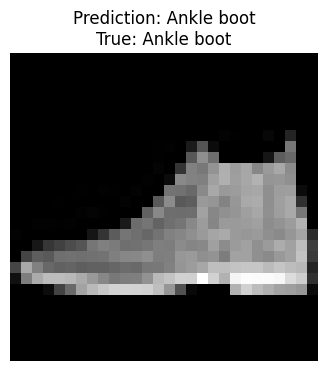

Single Image Prediction
Ground Truth : Ankle boot
Prediction   : Ankle boot
Confidence   : 82.40%


In [15]:
# ============================================================
# Single Image Prediction
# ============================================================

# Get one image from the test dataset
image, true_label = test_dataset[0]

# Add batch dimension: (1, 1, 28, 28)
image_batch = image.unsqueeze(0).to(device)

loaded_model.eval()

with torch.no_grad():

    logits = loaded_model(image_batch)

    probabilities = torch.softmax(
        logits,
        dim=1
    )

    predicted_class = probabilities.argmax(dim=1).item()

    confidence = probabilities.max().item()

# ------------------------------------------------------------
# Display Result
# ------------------------------------------------------------

plt.figure(figsize=(4,4))

plt.imshow(
    image.squeeze(),
    cmap="gray"
)

plt.title(
    f"Prediction: {classes[predicted_class]}\n"
    f"True: {classes[true_label]}"
)

plt.axis("off")
plt.show()

print("=" * 60)
print("Single Image Prediction")
print("=" * 60)

print(f"Ground Truth : {classes[true_label]}")
print(f"Prediction   : {classes[predicted_class]}")
print(f"Confidence   : {confidence:.2%}")

Batch Prediction
Batch Accuracy: 85.94%


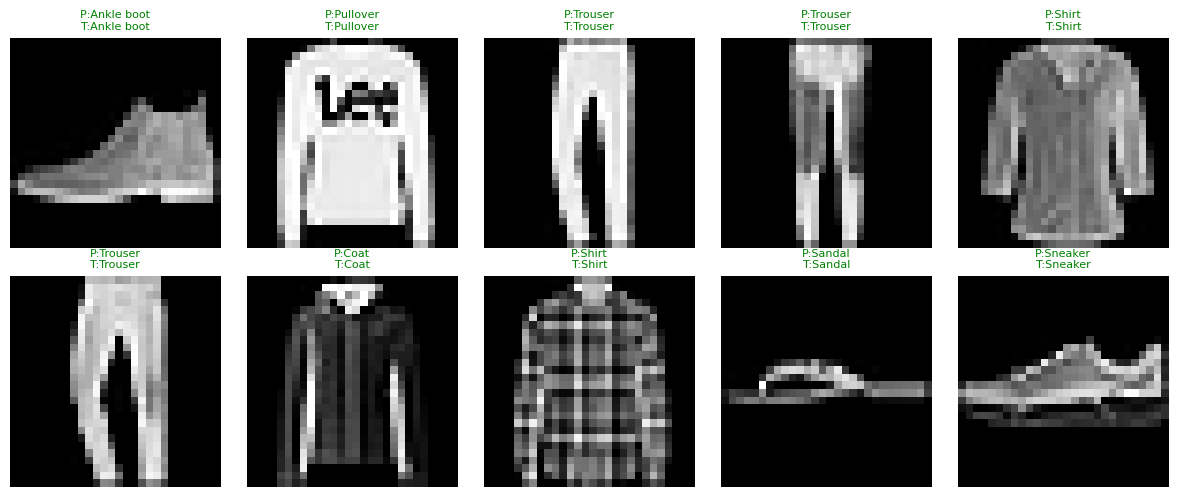


Predicted Classes in This Batch
T-shirt/top : 5
Trouser     : 7
Pullover    : 12
Dress       : 4
Coat        : 5
Sandal      : 5
Shirt       : 4
Sneaker     : 11
Bag         : 8
Ankle boot  : 3


In [16]:
# ============================================================
# Batch Prediction
# ============================================================

loaded_model.eval()

images, labels = next(iter(test_loader))

images = images.to(device)
labels = labels.to(device)

with torch.no_grad():

    logits = loaded_model(images)

    predictions = logits.argmax(dim=1)

batch_accuracy = (
    (predictions == labels)
    .float()
    .mean()
    .item()
)

print("=" * 60)
print("Batch Prediction")
print("=" * 60)

print(f"Batch Accuracy: {batch_accuracy:.2%}")

# ------------------------------------------------------------
# Visualize Predictions
# ------------------------------------------------------------

fig, axes = plt.subplots(2, 5, figsize=(12,5))

for ax, img, pred, true in zip(
    axes.flat,
    images[:10].cpu(),
    predictions[:10].cpu(),
    labels[:10].cpu()
):

    color = "green" if pred == true else "red"

    ax.imshow(
        img.squeeze(),
        cmap="gray"
    )

    ax.set_title(
        f"P:{classes[pred]}\nT:{classes[true]}",
        fontsize=8,
        color=color
    )

    ax.axis("off")

plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# Show Prediction Distribution
# ------------------------------------------------------------

unique, counts = torch.unique(
    predictions.cpu(),
    return_counts=True
)

print("\nPredicted Classes in This Batch")

for cls, count in zip(unique, counts):

    print(f"{classes[cls]:12}: {count.item()}")

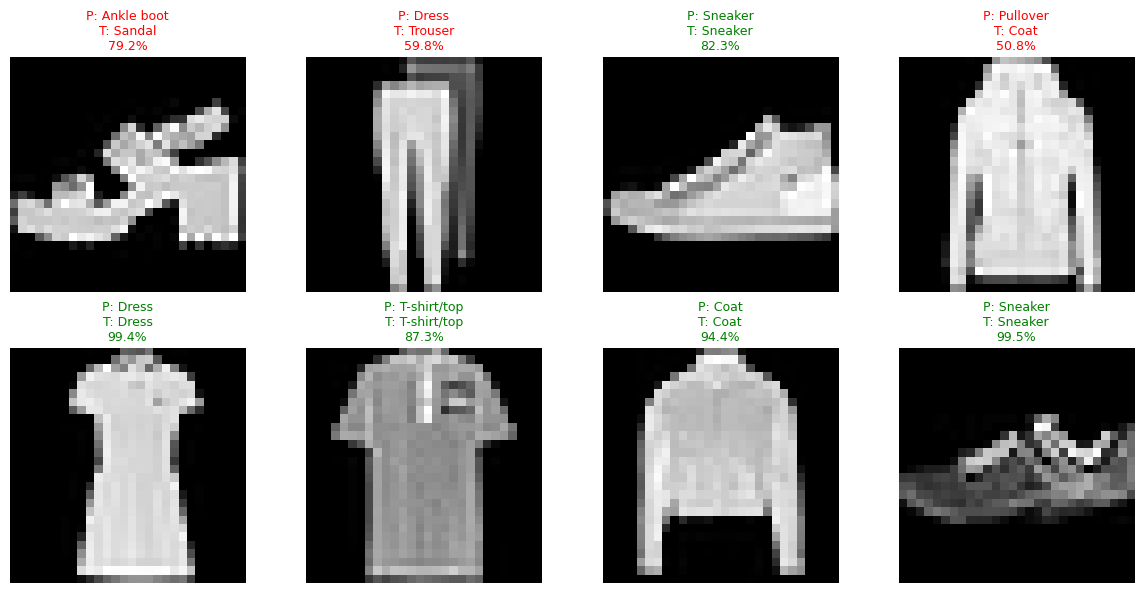

Random Inference Summary
Correct Predictions: 5/8
Accuracy: 62.50%


In [17]:
# ============================================================
# Inference on Random Test Images
# ============================================================

import random

loaded_model.eval()

num_samples = 8

indices = random.sample(
    range(len(test_dataset)),
    num_samples
)

fig, axes = plt.subplots(2, 4, figsize=(12, 6))

correct_predictions = 0

with torch.no_grad():

    for ax, idx in zip(axes.flat, indices):

        image, true_label = test_dataset[idx]

        image_batch = image.unsqueeze(0).to(device)

        logits = loaded_model(image_batch)

        probabilities = torch.softmax(
            logits,
            dim=1
        )

        confidence, prediction = torch.max(
            probabilities,
            dim=1
        )

        prediction = prediction.item()
        confidence = confidence.item()

        if prediction == true_label:
            correct_predictions += 1

        color = (
            "green"
            if prediction == true_label
            else "red"
        )

        ax.imshow(
            image.squeeze(),
            cmap="gray"
        )

        ax.set_title(
            f"P: {classes[prediction]}\n"
            f"T: {classes[true_label]}\n"
            f"{confidence:.1%}",
            color=color,
            fontsize=9
        )

        ax.axis("off")

plt.tight_layout()
plt.show()

print("=" * 60)
print("Random Inference Summary")
print("=" * 60)

print(f"Correct Predictions: {correct_predictions}/{num_samples}")
print(f"Accuracy: {correct_predictions/num_samples:.2%}")